# Análisis de Correspondencias Múltiples (MCA)

## Objetivo del análisis

El objetivo de este trabajo es analizar la relación existente entre distintas variables categóricas relacionadas con hábitos de vida y características sociodemográficas mediante Análisis de Correspondencias Múltiples (MCA).

A partir de un conjunto inicial de cinco variables categóricas (consumo de tabaco, frecuencia de consumo de alcohol, estado civil, nivel educativo y situación laboral), se analizan distintas combinaciones de tres variables con el fin de identificar patrones de asociación entre categorías.

Para cada combinación analizada, se aplica un MCA y posteriormente se complementa el análisis con técnicas de clustering jerárquico y no jerárquico (k-means) sobre las coordenadas factoriales de las categorías, con el objetivo de reforzar la interpretación estructural de los resultados.


## Importación de librerías

En esta sección se importan las librerías que se utilizarán a lo largo del análisis para la manipulación de datos, visualización, análisis factorial (MCA) y clustering.

In [14]:
# Análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# MCA
import prince

# Clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


## Lectura y preparación de los datos

Se cargan los datos y se seleccionan únicamente las variables de interés para el análisis. Posteriormente, se revisan posibles valores faltantes y se realiza una preparación inicial del conjunto de datos.


In [15]:
#Lectura de datos
df = pd.read_csv("C:/Users/joser/Downloads/medical_insurance.csv")

#Nos quedamos simplemente con las variables de interés a estudiar 
vars_mca = ['marital_status', 'employment_status', 'education','smoker','alcohol_freq']
df_mca = df[vars_mca].copy()
print(df_mca.head(20)) #mostramos las primeras 20 filas para ver cómo son los datos y si hay nulos


   marital_status employment_status     education   smoker alcohol_freq
0         Married           Retired     Doctorate    Never          NaN
1         Married          Employed         No HS    Never       Weekly
2         Married           Retired            HS    Never          NaN
3         Married     Self-employed  Some College    Never          NaN
4         Married     Self-employed     Doctorate    Never        Daily
5          Single          Employed            HS    Never        Daily
6          Single          Employed       Masters    Never   Occasional
7          Single          Employed            HS    Never       Weekly
8        Divorced           Retired         No HS  Current          NaN
9         Married          Employed     Bachelors    Never       Weekly
10       Divorced          Employed       Masters    Never   Occasional
11        Married          Employed            HS   Former   Occasional
12        Married          Employed       Masters    Never      

## Tratamiento de valores faltantes en la frecuencia de consumo de alcohol

En la variable de frecuencia de consumo de alcohol aparecen valores que el sistema interpreta como nulos (NaN), pero que en la práctica corresponden a individuos que no consumen alcohol.

Para evitar la pérdida de información y permitir su inclusión en el MCA, estos valores se recodifican como una categoría explícita ("Never").

In [16]:
df_mca["alcohol_freq"] = df["alcohol_freq"].fillna("Never")

#Veamos los conteos de cada variable y la cantidad de nulos
print("Conteos de variables y cantidad de nulos:\n")

print(df_mca["marital_status"].value_counts(), "\nCantidad de nulos:", df_mca["marital_status"].isna().sum(), "\n")

print(df_mca["employment_status"].value_counts(), "\nCantidad de nulos:", df_mca["employment_status"].isna().sum(), "\n")

print(df_mca["education"].value_counts(), "\nCantidad de nulos:", df_mca["education"].isna().sum(), "\n")

print(df_mca["smoker"].value_counts(), "\nCantidad de nulos:", df_mca["smoker"].isna().sum(), "\n")

print(df_mca["alcohol_freq"].value_counts(), "\nCantidad de nulos:", df_mca["alcohol_freq"].isna().sum(), "\n")

Conteos de variables y cantidad de nulos:

marital_status
Married     53252
Single      35715
Divorced     6984
Widowed      4049
Name: count, dtype: int64 
Cantidad de nulos: 0 

employment_status
Employed         55269
Retired          19864
Unemployed       12939
Self-employed    11928
Name: count, dtype: int64 
Cantidad de nulos: 0 

education
Bachelors       27996
Some College    25112
HS              24827
Masters         13987
No HS            5120
Doctorate        2958
Name: count, dtype: int64 
Cantidad de nulos: 0 

smoker
Never      69709
Former     18163
Current    12128
Name: count, dtype: int64 
Cantidad de nulos: 0 

alcohol_freq
Occasional    45078
Never         30083
Weekly        19833
Daily          5006
Name: count, dtype: int64 
Cantidad de nulos: 0 



## Análisis descriptivo de las variables categóricas

Se calculan frecuencias y porcentajes de cada variable con el objetivo de identificar categorías con baja representación. Estas categorías pueden agruparse antes del MCA para mejorar la estabilidad del análisis y facilitar la interpretación de los resultados.

In [17]:
for col in vars_mca:
    print(f"\nPorcentajes de {col}")
    display(
        (df_mca[col].value_counts(normalize=True) * 100)
        .round(3)
        .to_frame("Porcentaje (%)")
    )


Porcentajes de marital_status


,Porcentaje (%)
marital_status,
Married,53.252
Single,35.715
Divorced,6.984
Widowed,4.049



Porcentajes de employment_status


,Porcentaje (%)
employment_status,
Employed,55.269
Retired,19.864
Unemployed,12.939
Self-employed,11.928



Porcentajes de education


,Porcentaje (%)
education,
Bachelors,27.996
Some College,25.112
HS,24.827
Masters,13.987
No HS,5.120
Doctorate,2.958



Porcentajes de smoker


,Porcentaje (%)
smoker,
Never,69.709
Former,18.163
Current,12.128



Porcentajes de alcohol_freq


,Porcentaje (%)
alcohol_freq,
Occasional,45.078
Never,30.083
Weekly,19.833
Daily,5.006


## Recodificación de categorías con baja frecuencia

Con el fin de mejorar la estabilidad y la interpretabilidad del MCA, se agrupan categorías con baja masa relativa en modalidades conceptualmente afines.

La recodificación se realiza en un nuevo conjunto de datos para no modificar las variables originales, manteniendo la trazabilidad entre variables originales y recodificadas.


In [18]:
df_mca_rec = df_mca.copy()

# Education (recodificamos)
df_mca_rec["education_rec"] = df_mca_rec["education"].replace({
    "Doctorate": "Higher Education",
    "Masters": "Higher Education",
    "HS": "Low or No Formal Education",
    "No HS": "Low or No Formal Education"
})

# Employment status
df_mca_rec["employment_status_rec"] = df_mca_rec["employment_status"]

# Marital status (recodificamos)
df_mca_rec["marital_status_rec"] = df_mca_rec["marital_status"].replace({
    "Divorced": "Single",
    "Widowed": "Married", 
}) 

#Smoker 
df_mca_rec["smoker_rec"] = df_mca_rec["smoker"]

# Alcohol frequency
df_mca_rec["alcohol_freq_rec"] = df_mca_rec["alcohol_freq"].replace({
    "Daily": "Weekly",
})

#Ajustamos según la combinación de categorías que queramos analizar
df_mca_final = df_mca_rec[
    ["marital_status_rec","smoker_rec","alcohol_freq_rec"]
].copy()

df_mca_final.head()


,marital_status_rec,smoker_rec,alcohol_freq_rec
0,Married,Never,Never
1,Married,Never,Weekly
2,Married,Never,Never
3,Married,Never,Never
4,Married,Never,Weekly


# MCA: Estado civil, consumo de tabaco y frecuencia de consumo de alcohol

En este primer análisis se aplica un MCA a las variables recodificadas de estado civil, consumo de tabaco y frecuencia de consumo de alcohol, ya que consideramos que se pueden sacar conclusiones interesantes de las agrupaciones entre grupos (sabemos de pruebas previas que es la combinación de variables que tiene un poder explicativo mayor en las dos primera dimensiones, a pesar de que más de dos autovalores están por encima de 0.2, como hemos mencionado nos limitaremos a usar 2 ejes para sacar nuestras conclusiones).

Otra combinación interesante con un poder explicativo ligeramente menor pero con agrupaciones también muy interesantes es la de consumo de tabaco, nivel educativo y situación laboral. Bastaría con realizar ligeras modificaciones en el código para realizar el análisis de cualquier combinación de estas 5 variables.

El objetivo es identificar asociaciones estructurales entre las categorías y representarlas en un espacio factorial de dimensión reducida, en este caso 2 dimensiones, facilitando la interpretación conjunta de patrones de consumo y estado civil.

In [19]:
# Análisis de Correspondencias Múltiples (MCA)
df_mca_final = df_mca_final.astype('category')


#Número máximo de dimensiones con el que se consigue el 100% de la varianza es igual a número total de categorías 
#entre todas las variables  menos el propio número de variables

mca = prince.MCA(
    n_components=5, #Usamos comunmente 2 dimensiones para visualización y análisis 
    n_iter=100,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mca = mca.fit(df_mca_final)

## Resumen de inercia y elección del plano factorial

Se presenta el resumen de autovalores e inercia explicada por dimensión con el fin de seleccionar el número de dimensiones a interpretar.

En este trabajo se prioriza la interpretación en el plano formado por las dos primeras dimensiones, dado que permite una representación visual directa de las asociaciones principales entre categorías, la inclusión de una tercera o 4ta dimensión debe estar fuertemente justificada. 

In [20]:
# 5. RESUMEN DE INERCIA y AUTOVALORES

eigs = mca.eigenvalues_
pct = mca.percentage_of_variance_ 
pct_acum = mca.cumulative_percentage_of_variance_ 
inercia_df = pd.DataFrame({
    "Autovalor": eigs,
    "% Varianza": pct,
    "% Acumulada": pct_acum
})

inercia_df.index = [f"Dim {i+1}" for i in range(len(eigs))]

print("\n=== RESUMEN DE INERCIA ===")
display(inercia_df.round(4))


=== RESUMEN DE INERCIA ===


,Autovalor,% Varianza,% Acumulada
Dim 1,0.3367,20.2004,20.2004
Dim 2,0.3356,20.1384,40.3388
Dim 3,0.3332,19.9937,60.3324
Dim 4,0.3314,19.8861,80.2185
Dim 5,0.3297,19.7815,100.0000


### Inercia explicada y elección del plano factorial

La descomposición de la inercia muestra que las dos primeras dimensiones del Análisis de Correspondencias Múltiples explican conjuntamente aproximadamente un **40% de la inercia total**.

Este nivel de inercia acumulada permite representar una parte sustancial de la estructura asociativa entre las categorías en un plano bidimensional, manteniendo un equilibrio adecuado entre simplificación y capacidad explicativa.

Se considera que el plano definido por las dos primeras dimensiones resulta apropiado para la interpretación de las relaciones entre categorías y para la aplicación de análisis complementarios.


## Coordenadas de las categorías

A continuación se muestran las coordenadas factoriales de cada categoría en las distintas dimensiones.

Estas coordenadas representan la posición de cada modalidad en el espacio factorial. Categorías cercanas entre sí tienden a estar asociadas, mientras que categorías situadas en direcciones opuestas suelen reflejar patrones contrastados.

## Contribuciones de las categorías

Se presentan además las contribuciones de cada categoría a las dimensiones factoriales.

Las contribuciones permiten identificar qué modalidades son más relevantes en la construcción de cada eje, y por tanto ayudan a interpretar el significado sustantivo de las dimensiones antes de observar el mapa factorial.

In [21]:
# 6. COORDENADAS DE LAS CATEGORÍAS

coords = mca.column_coordinates(df_mca_final)
coords.index.name = "Categoría"

print("\n=== COORDENADAS DE LAS CATEGORÍAS ===")
display(coords.round(4))

# 7. CONTRIBUCIONES DE LAS CATEGORÍAS

try:
    contrib = mca.column_contributions_
    contrib.index.name = "Categoría"
    print("\n=== CONTRIBUCIONES DE LAS CATEGORÍAS ===")
    display(contrib.round(4))
except AttributeError:
    print("La versión de prince no soporta 'column_contributions_'.")



=== COORDENADAS DE LAS CATEGORÍAS ===


,0,1,2,3,4
Categoría,,,,,
marital_status_rec__Married,0.5881,-0.1681,0.0565,-0.2874,-0.5341
marital_status_rec__Single,-0.7892,0.2256,-0.0758,0.3856,0.7168
smoker_rec__Current,1.6842,-0.4572,0.6175,1.5469,1.1941
smoker_rec__Former,-0.1063,1.5863,-0.2123,0.8638,-1.0895
smoker_rec__Never,-0.2653,-0.3338,-0.0521,-0.4942,0.0761
alcohol_freq_rec__Never,-0.5250,-0.4002,1.2369,0.3382,-0.4940
alcohol_freq_rec__Occasional,0.0668,-0.3455,-1.0026,0.2879,-0.0802
alcohol_freq_rec__Weekly,0.5147,1.1117,0.3215,-0.9320,0.7437



=== CONTRIBUCIONES DE LAS CATEGORÍAS ===


,0,1,2,3,4
Categoría,,,,,
marital_status_rec__Married,0.1962,0.0161,0.0018,0.0476,0.1653
marital_status_rec__Single,0.2633,0.0216,0.0025,0.0639,0.2218
smoker_rec__Current,0.3406,0.0252,0.0463,0.2919,0.1748
smoker_rec__Former,0.0020,0.4539,0.0082,0.1363,0.2180
smoker_rec__Never,0.0486,0.0771,0.0019,0.1712,0.0041
alcohol_freq_rec__Never,0.0821,0.0478,0.4604,0.0346,0.0742
alcohol_freq_rec__Occasional,0.0020,0.0534,0.4533,0.0376,0.0029
alcohol_freq_rec__Weekly,0.0652,0.3049,0.0257,0.2170,0.1389


## Expectativas factoriales a partir de contribuciones (Dim 1 y Dim 2)

Antes de visualizar el mapa factorial, podemos anticipar qué categorías van a dominar cada dimensión observando sus **contribuciones** y el **signo/magnitud** de sus coordenadas.

### Dimensión 1 (principal)
Las mayores contribuciones a Dim 1 corresponden a:
- `smoker_rec__Current` (0.3406)
- `marital_status_rec__Single` (0.2633)
- `marital_status_rec__Married` (0.1962)

Por tanto, esperamos que Dim 1 esté definida sobre todo por un contraste entre:
- **Polo positivo (Dim1 > 0):** `smoker_rec__Current` (1.6842), `marital_status_rec__Married` (0.5881) y `alcohol_freq_rec__Weekly` (0.5147), que deberían aparecer relativamente próximos entre sí en el lado derecho del plano.
- **Polo negativo (Dim1 < 0):** `marital_status_rec__Single` (-0.7892) y categorías asociadas a menor consumo/ausencia (`alcohol_freq_rec__Never` -0.5250, `smoker_rec__Never` -0.2653), que deberían agruparse en el lado izquierdo.

En consecuencia, **esperamos una oposición clara** entre *Current/Married/Weekly* frente a *Single/Never* en el eje horizontal.

### Dimensión 2 (secundaria)
Las mayores contribuciones a Dim 2 corresponden a:
- `smoker_rec__Former` (0.4539)
- `alcohol_freq_rec__Weekly` (0.3049)

Esto sugiere que Dim 2 estará marcada por categorías que deberían quedar muy arriba/abajo:
- **Polo positivo (Dim2 > 0):** `smoker_rec__Former` (1.5863) y `alcohol_freq_rec__Weekly` (1.1117), que deberían aparecer **muy elevados** y relativamente cercanos en el eje vertical.
- **Polo negativo (Dim2 < 0):** categorías como `smoker_rec__Current` (-0.4572), `alcohol_freq_rec__Never` (-0.4002) y `alcohol_freq_rec__Occasional` (-0.3455), que tenderían a situarse más abajo.

Así, **esperamos que la separación vertical** del plano esté dominada por el contraste entre *Former/Weekly* (arriba) frente a *Current/Never/Occasional* (abajo).


## Mapa factorial de categorías (Dimensión 1 vs Dimensión 2)

Se representa el plano factorial formado por las dos primeras dimensiones, incorporando en los ejes el porcentaje de inercia explicado por cada una.

Este mapa permite interpretar de forma conjunta las asociaciones entre categorías: modalidades próximas tienden a aparecer en perfiles similares, mientras que modalidades alejadas o en direcciones opuestas reflejan patrones diferenciados.


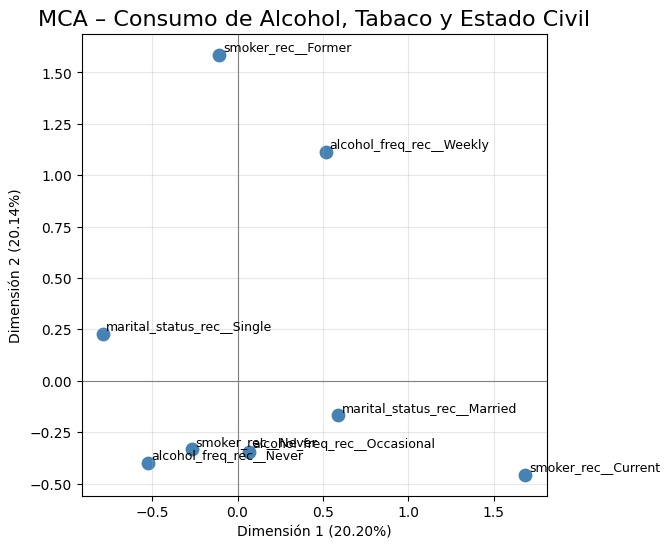

In [22]:
# 8. MAPA FACTORIAL CON % OFICIALES EN LOS EJES


# Usamos directamente los comandos nativos para sacar los % reales
var_dim1 = mca.percentage_of_variance_[0] 
var_dim2 = mca.percentage_of_variance_[1] 

plt.figure(figsize=(6, 6))

for label, x, y in zip(coords.index, coords[0], coords[1]):
    plt.scatter(x, y, s=80, color="steelblue")
    plt.text(x + 0.02, y + 0.02, label, fontsize=9)

plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title("MCA – Consumo de Alcohol, Tabaco y Estado Civil", fontsize=16)
plt.xlabel(f"Dimensión 1 ({var_dim1:.2f}%)")
plt.ylabel(f"Dimensión 2 ({var_dim2:.2f}%)")
plt.grid(alpha=0.3)
plt.show()

## Interpretación del mapa factorial

A partir de la distribución de las categorías en el plano factorial se identifican relaciones de proximidad y oposición entre modalidades.

Las categorías situadas más alejadas del origen desempeñan un papel más destacado en la estructura observada, mientras que aquellas cercanas al origen tienden a tener menor capacidad discriminante dentro del plano interpretado.

## Clustering sobre las coordenadas de las categorías: motivación

Para reforzar la interpretación del mapa factorial y sintetizar la estructura observada, se aplica un análisis clúster sobre las coordenadas factoriales de las categorías.

En este caso, el clustering se utiliza como herramienta descriptiva para agrupar modalidades próximas en el espacio factorial, facilitando la identificación de bloques de categorías con comportamiento similar.

## Clustering jerárquico (Ward) y elección del número de clusters

Se aplica un clustering jerárquico mediante el método de Ward, que agrupa categorías minimizando la variabilidad interna de los grupos en cada fusión.

El dendrograma resultante permite decidir un número razonable de clusters observando los saltos en la distancia de fusión. En este análisis se seleccionan **3 clusters**, ya que capturan la estructura principal sin sobrerreducirla (k=2) ni fragmentarla en exceso (k>3).


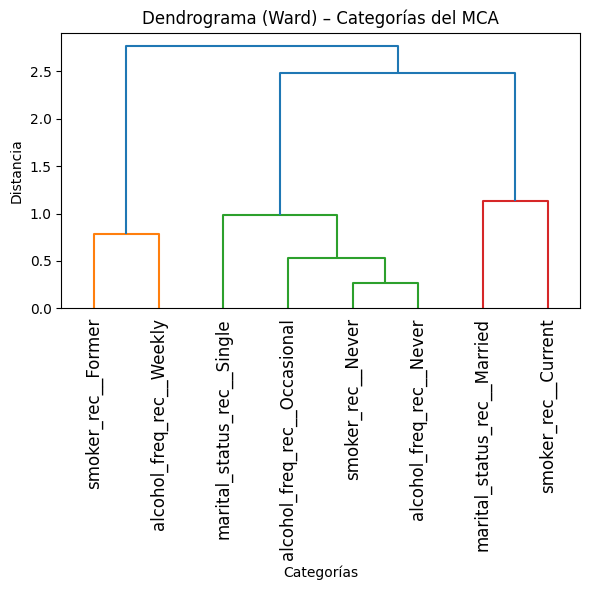

In [23]:
# Nos quedamos con Dim 1 y Dim 2 (columnas 0 y 1 en prince)
C = coords[[0, 1]].copy()
C.columns = ["Dim1", "Dim2"]
Zc = linkage(C.values, method="ward")

plt.figure(figsize=(6, 6))
dendrogram(Zc, labels=C.index.astype(str), leaf_rotation=90)
plt.title("Dendrograma (Ward) – Categorías del MCA")
plt.xlabel("Categorías")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()


In [24]:
k_h = 3 # <-- cambia a 2,3,4... según dendrograma y mapa factorial
cat_cluster_h = fcluster(Zc, t=k_h, criterion="maxclust")

C_h = C.copy()
C_h["cluster"] = cat_cluster_h
C_h.head(8)


,Dim1,Dim2,cluster
Categoría,,,
marital_status_rec__Married,0.588098,-0.168109,3
marital_status_rec__Single,-0.789213,0.225598,2
smoker_rec__Current,1.684204,-0.457191,3
smoker_rec__Former,-0.106251,1.586280,1
smoker_rec__Never,-0.265334,-0.333770,2
alcohol_freq_rec__Never,-0.525039,-0.400195,2
alcohol_freq_rec__Occasional,0.066770,-0.345487,2
alcohol_freq_rec__Weekly,0.514709,1.111676,1


## Visualización de los clusters jerárquicos en el plano factorial

A continuación se representa el plano factorial del MCA con las categorías coloreadas según la partición en **tres clusters** obtenida mediante el método jerárquico de Ward.

Esta representación permite observar cómo se distribuyen los tres grupos de categorías en el espacio definido por las dos primeras dimensiones.



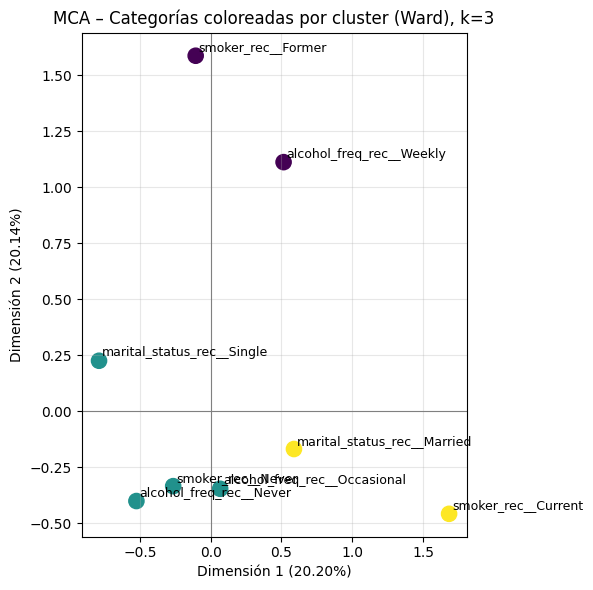

In [25]:
plt.figure(figsize=(6, 6))

plt.scatter(C_h["Dim1"], C_h["Dim2"], c=C_h["cluster"], s=120)

for label, x, y in zip(C_h.index.astype(str), C_h["Dim1"], C_h["Dim2"]):
    plt.text(x + 0.02, y + 0.02, label, fontsize=9)

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title(f"MCA – Categorías coloreadas por cluster (Ward), k={k_h}")
plt.xlabel(f"Dimensión 1 ({var_dim1:.2f}%)")
plt.ylabel(f"Dimensión 2 ({var_dim2:.2f}%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Clustering no jerárquico (k-means) y comparación de resultados

Se aplica k-means con el mismo número de clusters (k=3) con el objetivo de contrastar si la partición es consistente con la estructura detectada por el método jerárquico.

La coincidencia entre ambos métodos refuerza la robustez de los grupos encontrados y sugiere que los clusters reflejan patrones estables en la disposición factorial de las categorías.


## Visualización de los clusters k-means en el plano factorial

A continuación se representa el plano factorial del MCA con las categorías coloreadas según la partición en **tres clusters** obtenida mediante el algoritmo k-means.

Este gráfico permite comparar visualmente la distribución de los clusters con la obtenida mediante el clustering jerárquico.


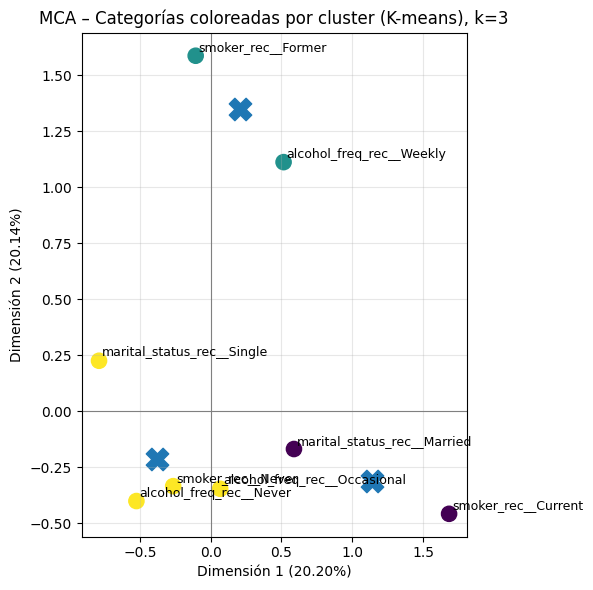

In [26]:
k_km = 3
kmeans_cat = KMeans(n_clusters=k_km, n_init=50, random_state=42)
cat_cluster_km = kmeans_cat.fit_predict(C.values)

C_km = C.copy()
C_km["cluster"] = cat_cluster_km

centers = kmeans_cat.cluster_centers_

plt.figure(figsize=(6, 6))
plt.scatter(C_km["Dim1"], C_km["Dim2"], c=C_km["cluster"], s=120)
plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=260)  # centroides

for label, x, y in zip(C_km.index.astype(str), C_km["Dim1"], C_km["Dim2"]):
    plt.text(x + 0.02, y + 0.02, label, fontsize=9)

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title(f"MCA – Categorías coloreadas por cluster (K-means), k={k_km}")
plt.xlabel(f"Dimensión 1 ({var_dim1:.2f}%)")
plt.ylabel(f"Dimensión 2 ({var_dim2:.2f}%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Conclusiones del análisis MCA

El Análisis de Correspondencias Múltiples (MCA) aplicado a las variables de estado civil, consumo de tabaco y frecuencia de consumo de alcohol permite identificar una estructura clara de asociaciones entre categorías, que se manifiesta de forma coherente tanto en el mapa factorial como en los análisis clúster realizados posteriormente.

Las dos primeras dimensiones del MCA explican conjuntamente aproximadamente un 40% de la inercia total, lo que permite una representación bidimensional adecuada de las relaciones principales entre las categorías analizadas. Este plano factorial recoge los contrastes más relevantes entre modalidades y constituye una base sólida para la interpretación estructural del fenómeno estudiado.

El análisis clúster jerárquico, aplicado a las coordenadas factoriales de las categorías mediante el método de Ward, sugiere de forma consistente la existencia de tres grupos bien diferenciados. Esta elección se apoya en la presencia de saltos claros en la distancia de fusión observados en el dendrograma. La posterior aplicación del algoritmo k-means con el mismo número de clusters reproduce una partición muy similar, lo que refuerza la estabilidad y robustez de la estructura identificada.

El primer cluster agrupa las categorías *smoker_rec_Former* y *alcohol_freq_rec_Weekly*. Estas modalidades aparecen próximas entre sí tanto en el espacio factorial como en el dendrograma, lo que indica una asociación entre haber sido fumador y un consumo de alcohol relativamente regular. Este grupo puede interpretarse como un patrón vinculado a hábitos de consumo pasados o moderados, claramente diferenciado de las categorías asociadas a la ausencia de consumo y del consumo actual de tabaco.

El segundo cluster está formado por las categorías *smoker_rec_Never*, *alcohol_freq_rec_Never*, *alcohol_freq_rec_Occasional* y *marital_status_rec_Single*. Este conjunto representa un perfil caracterizado por la ausencia o baja frecuencia de consumo de sustancias, asociado principalmente al estado civil soltero. La proximidad de estas categorías y su localización relativamente cercana al origen del plano factorial sugieren un patrón más homogéneo y menos extremo, con menor capacidad discriminante respecto a los polos definidos por otros clusters.

El tercer cluster agrupa las categorías *smoker_rec_Current* y *marital_status_rec_Married*. Estas modalidades aparecen situadas en posiciones extremas del plano factorial, especialmente a lo largo de la primera dimensión, lo que indica que desempeñan un papel relevante en la definición de los contrastes principales del análisis. Este grupo define uno de los polos más marcados del espacio factorial y refleja una asociación clara entre el consumo actual de tabaco y el estado civil casado.

La coherencia observada entre el mapa factorial del MCA de nuestros datos, el dendrograma jerárquico y los resultados del clustering no jerárquico confirma que los grupos identificados responden a patrones estructurales reales de asociación entre las categorías analizadas. En conjunto, el análisis pone de manifiesto la existencia de distintos polos de comportamiento relacionados con hábitos de consumo y estado civil.
